# Titanic Dataset

 **Project notebook or section dedicated to loading, cleaning, and modeling the Titanic passenger data.**

## Train 1 Label Encoding

## Importation of Packages
**Pandas**: Manages and clean tabular data.  

**Numpy**: Performs fast mathematical calculations on large number arrays.  

**Matplotlib**: Creates a visual graphs, charts and plots from data

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Loading Titanic Dataset
This code loads the titanic dataset into the jupiter notebook

In [34]:
df_titanic=pd.read_csv('titanic.csv')

## Loading Titanic Age Dataset
This code loads the titanic dataset into the jupiter notebook

In [35]:
df_titanic_age=pd.read_csv('Titanic_Ages_missing.csv')

## Loading Titanic Embarked Dataset
This code loads the titanic dataset into the jupiter notebook

In [36]:
df_titanic_embarked=pd.read_csv('Titanic_Ages - Embarked.csv')

## Preview of rows(Titanic Dataset)
This code displays the first 5 rows of your dataset that you can visually inspect 

In [37]:
df_titanic.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Preview of rows(Titanic Age Dataset)
This code displays the first 5 rows of your dataset that you can visually inspect 

In [38]:
df_titanic_age.head(5)

,Name,Age
0,"Moran, Mr. James",22
1,"Williams, Mr. Charles Eugene",23
2,"Masselmani, Mrs. Fatima",22
3,"Emir, Mr. Farred Chehab",29
4,"O'Dwyer, Miss. Ellen ""Nellie""",22


## Preview of rows(Titanic Embarked Dataset)
This code displays the first 5 rows of your dataset that you can visually inspect 

In [39]:
df_titanic_embarked.head(5)

,Name,Embarked
0,"Icard, Miss. Amelie",S
1,"Stone, Mrs. George Nelson (Martha Evelyn)",S
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN


## Summary of the Dataset
It prints a condensed overview of the dataframe.  

 **Key Insights Provided:**  
 
Total row count.  

Complete column list.  

Missing value counts.  

Data type mapping.  

Memory usage details.

In [40]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     1309 non-null   int64  
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(2), int64(5), object(5)
memory usage: 122.8+ KB


## Summary of the Dataset
It prints a condensed overview of the dataframe.  

 **Key Insights Provided:**  
 
* Total row count.  

* Complete column list.  

Missing value counts.  

Data type mapping.  

Memory usage details.

In [41]:
df_titanic_age.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264 entries, 0 to 263
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Name    264 non-null    object
 1   Age     264 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 4.2+ KB


##  Imputing Missing Titanic Passenger Ages via Dataframe Mapping
Fills missing values in df_titanic['Age'] by mapping passenger names to ages from a clean reference dataframe.

In [42]:
# Name ---> Age lookup from the clean dataframe
age_lookup=df_titanic_age.set_index('Name')['Age']

# fill only the missing ages in df, matched by name
df_titanic['Age']= df_titanic['Age'].fillna(df_titanic['Name'].map(age_lookup))

## Filtering Missing Values
 Identifies rows where passenger age is missing.

In [43]:
df_titanic[df_titanic['Age'].isna()] 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
454,455,0,3,"Peduzzi, Mr. Joseph",male,NaN,0,0,A/5 2817,8.05,NaN,S


## Imputing Missing Age
Finds a specific passenger by name and manually assigns an age of 24.

In [44]:
mask= df_titanic['Name'].str.contains('Peduzzi, Mr. Joseph', na=False)
df_titanic.loc[mask, 'Age'] =24

## Verifying Imputation
Checks the dataset again to confirm no missing values remain.

In [45]:
df_titanic[df_titanic['Age'].isna()] 


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


##  Imputing Missing Titanic Passenger Embarked via Dataframe Mapping
Fills missing values in df_titanic['Embarked'] by mapping passenger names to embarked from a clean reference dataframe.

In [46]:
# Drop duplicates from the DataFrame first, then set the index
embarked_lookup = df_titanic_embarked.drop_duplicates(subset=['Name']).set_index('Name')['Embarked']

# Fill missing values normally
df_titanic['Embarked'] = df_titanic['Embarked'].fillna(df_titanic['Name'].map(embarked_lookup))


In [47]:
df_titanic[df_titanic['Embarked'].isna()] 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


## Removal of columns
This code removes the column names **Cabin** from the dataset as **Survived** as a target variable. **x** saved the remaining columns into a new variable so that the adat remained untouched.

In [48]:
x=df_titanic.drop(['Cabin', 'Survived'], axis =1)

## Extraction of Target Variable
This code extracts your target variable (the label you want to predict) and stores it separately. y saves this single column into a new variable named y 

In [49]:
y= df_titanic['Survived']

## Filling missing values 
This code fills the missing values of the **Column Age** with median and also fill the missing single **Fare** with the median fare. 

In [50]:
x['Age']=x['Age'].fillna(x['Age'].median())

#Fill the missing single Fare with the median fare
x['Fare']=x['Fare'].fillna(x['Fare'].median())


#Fill the missing Embarked with the most coomon port(mode)
x['Embarked']=x['Embarked'].fillna(x['Embarked'].mode()[0])


## Visualizing Class Distribution
Plots a bar chart showing the frequency counts of the binary target variable.

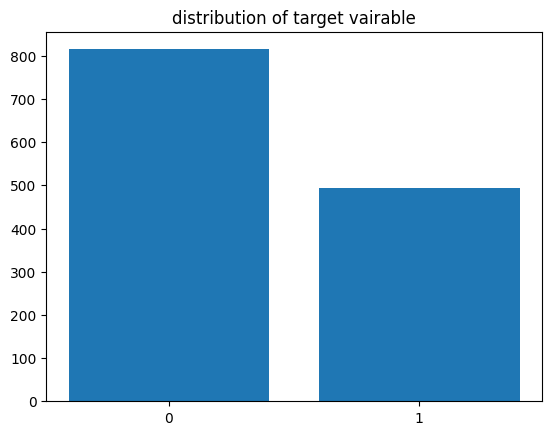

In [51]:
x_plot=y.value_counts()
plt.bar(x_plot.index, x_plot)
plt.gca().set_xticks([0,1])
plt.title('distribution of target vairable')
plt.show()

## Importing LabelEncoder
Imports scikit-learn's LabelEncoder utility to convert categorical text data into numerical integers.

In [52]:
from sklearn.preprocessing import LabelEncoder

## Encoding Categorical Features
Loops through columns in x, applying LabelEncoder to text columns while copying numerical columns as-is into a new train DataFrame.

In [53]:
train=pd.DataFrame()
label=LabelEncoder()
for c in x.columns:
    if(x[c].dtype=='object'):
        train[c]=label.fit_transform(x[c])
    else:
        train[c]=x[c]

## Previewing Processed Data
Displays the first five rows of the newly encoded train DataFrame to verify the transformation.

In [54]:
train.head(5)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,3,155,1,22.0,1,0,720,7.2500,2
1,2,1,286,0,38.0,1,0,816,71.2833,0
2,3,3,523,0,26.0,0,0,914,7.9250,2
3,4,1,422,0,35.0,1,0,65,53.1000,2
4,5,3,22,1,35.0,0,0,649,8.0500,2


## Importing Modeling Dependencies
Imports scikit-learn modules for data splitting, cross-validation, Logistic Regression modeling, and accuracy evaluation.

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn import base

## Defining Logistic Regression Pipeline
Defines a custom function to split data into train/test sets, train a Logistic Regression model, and print its baseline accuracy.

In [56]:
def logistic(x,y):
    x_train, x_test, y_train, y_test=train_test_split(x, y, random_state=42, test_size=0.2)
    lr=LogisticRegression(max_iter=1000)
    lr.fit(x_train, y_train)
    y_pre=lr.predict(x_test)
    print('Accuracy:', accuracy_score(y_test, y_pre))
                                                      

## Evaluating Model Performance
Runs the defined logistic pipeline on the processed train features and target variable y to output the validation accuracy.

In [57]:
logistic (train,y)

Accuracy: 0.8435114503816794


## Inspecting Dataframe Columns
Retrieves the column names of the original df_titanic DataFrame to review available features for future engineering.

In [58]:
df_titanic.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

# Train 2 (One Hot Encoding)

## Importing Encoding Utilities
Imports scikit-learn's OneHotEncoder class for transforming categorical string variables into binary vectors.

In [59]:
from sklearn.preprocessing import OneHotEncoder

## One-Hot Encoding Categorical Features
Applies pd.get_dummies() to convert the Sex and Embarked columns into binary numeric columns.

In [67]:
train_2 = pd.get_dummies(x,columns=['Sex', 'Embarked'],dtype=np.int8)

## Dropping High-Cardinality Text Features
Removes non-numeric text columns (PassengerId, Name, Ticket) that cannot be processed by the regression model.

In [68]:
train_2 = train_2.drop(columns=['PassengerId', 'Name', 'Ticket'])

## Previewing Encoded Dataframe
Displays the first five rows of train_2 to verify successful encoding and column removal.

In [69]:
train_2.head(5)

,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,0,1,0,0,1
1,1,38.0,1,0,71.2833,1,0,1,0,0
2,3,26.0,0,0,7.9250,1,0,0,0,1
3,1,35.0,1,0,53.1000,1,0,0,0,1
4,3,35.0,0,0,8.0500,0,1,0,0,1


## Importing Model Evaluation Dependencies
Packages scikit-learn functions required for data splitting, Logistic Regression modeling, and scoring metric calculations.

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn import base

## Defining Machine Learning Pipeline
Establishes a custom function to split inputs, train a Logistic Regression model, and print accuracy metrics.

In [71]:
def logistic(x, y):
    x_train2, x_test2, y_train2, y_test2 = train_test_split(
        x, y, random_state=42, test_size=0.2)

    lr = LogisticRegression(max_iter=1000)
    lr.fit(x_train2, y_train2)
    y_pre2 = lr.predict(x_test2)
    print('Accuracy:', accuracy_score(y_test2, y_pre2))

## Training and Evaluating Pipeline
Executes the logistic modeling function using the fully numeric train_2 features and returns validation accuracy.

In [72]:
logistic (train_2,y)

Accuracy: 0.851145038167939
